In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Data Loading and Initial Preparation ---
try :
    df = pd.read_csv("Housing.csv")
    print("--successfully loaded dataset...")
except FileNotFoundError:
    print("--file not found, enter the correct filepath...")

--successfully loaded dataset...


In [63]:
# --- Statistical Summary ---
print(df.info())
print()

numerical_df = df.select_dtypes(include = 'number')
categorical_df = df.select_dtypes(include = 'object')

print(numerical_df.mean())
print()
print(numerical_df.median())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

price        4.766729e+06
area         5.150541e+03
bedrooms     2.965138e+00
bathrooms    1.286239e+00
stories      1.805505e+00
parking      6.935

In [64]:
# --- Feature Engineering & Transformation ---

df["area_log"] = np.log(df["area"])
df.drop('area', axis = 1, inplace = True)

df["price_log"] = np.log(df["price"])
df.drop('price', axis = 1, inplace = True)

df = pd.get_dummies(df, columns = categorical_df.columns, drop_first = True)

print(df.head(5))

   bedrooms  bathrooms  stories  parking  area_log  price_log  mainroad_yes  \
0         4          2        3        2  8.911934  16.403275          True   
1         4          4        4        3  9.100526  16.321036          True   
2         3          2        2        2  9.206332  16.321036          True   
3         4          2        2        3  8.922658  16.318175          True   
4         4          1        2        2  8.911934  16.250001          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_u

In [65]:

X = df.drop('price_log', axis = 1)
y = df['price_log']

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# ---  Feature Scaling (Standardization) ---
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

# --- Model Training ---
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

LinearRegression()

In [66]:
# --- Model Evaluation and Interpretation ---
y_pred = lin_model.predict(X_test_scaled)

print(f"r2_score : {r2_score(y_test, y_pred)}")
print(f"mae : {mean_absolute_error(y_test, y_pred)}")
print(f"mse : {mean_squared_error(y_test, y_pred)}")
print(f"intercept : {lin_model.intercept_}")
coefficients_df = pd.DataFrame({'Features' : X.columns, 'Coefficients' : lin_model.coef_})
print(coefficients_df)

r2_score : 0.6782341334497212
mae : 0.19978911295152774
mse : 0.062129363435032024
intercept : 15.301070905357893
                           Features  Coefficients
0                          bedrooms      0.015212
1                         bathrooms      0.088154
2                           stories      0.070872
3                           parking      0.028276
4                          area_log      0.117739
5                      mainroad_yes      0.031043
6                     guestroom_yes      0.013871
7                      basement_yes      0.049912
8               hotwaterheating_yes      0.028860
9               airconditioning_yes      0.067199
10                     prefarea_yes      0.056402
11  furnishingstatus_semi-furnished     -0.002488
12     furnishingstatus_unfurnished     -0.053272


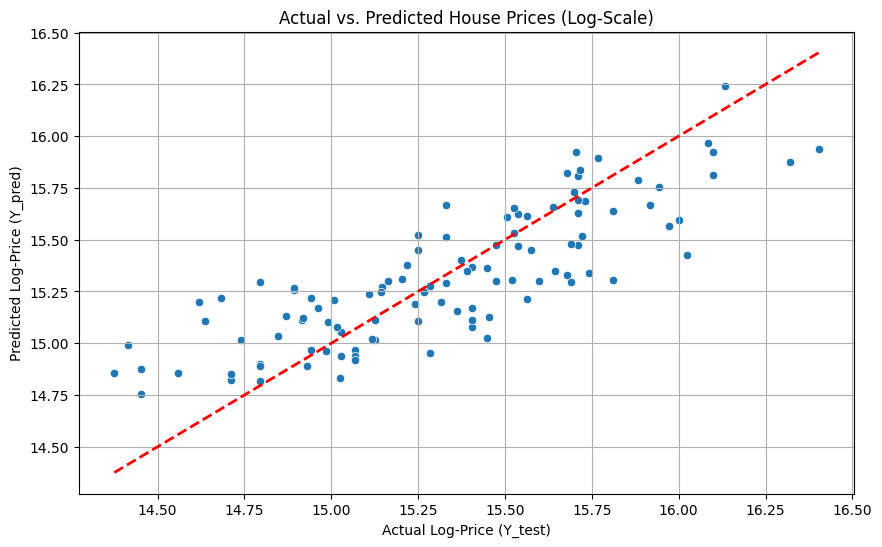

In [67]:
# --- Visual Test for the Model's Performance and Goodness-of-Fit ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)

# The ideal prediction line (y=x)
# This shows what a perfect model would predict.
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 
         color='red', linestyle='--', linewidth=2) 

plt.xlabel("Actual Log-Price (Y_test)")
plt.ylabel("Predicted Log-Price (Y_pred)")
plt.title("Actual vs. Predicted House Prices (Log-Scale)")
plt.grid(True)
plt.show()